In [3]:
import pandas as pd
url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv"
df = pd.read_csv(url)
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


In [5]:
df.shape

(22029, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [7]:
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000
mean,11015.000000,4.757232,5522.740842,182.863648,2223.807572,50610.402787,6.582323
std,6359.368876,0.960393,2597.666260,301.619721,1394.166380,28542.979123,1.458804
min,1.000000,2.015723,1000.000000,-98.300000,30.000000,1001.000000,4.000000
25%,5508.000000,4.130705,3286.000000,-4.080000,1067.000000,25804.000000,5.000000
50%,11015.000000,4.761527,5525.000000,93.650000,2088.000000,50858.000000,7.000000
75%,16522.000000,5.429335,7766.000000,247.310000,3212.000000,75165.000000,8.000000
max,22029.000000,7.469907,9999.000000,3109.790000,6887.000000,99999.000000,9.000000


In [8]:
df['Campaign_ID'].nunique()

22029

In [10]:
df['Customer_Segment'].unique()

array(['Tech Enthusiasts', 'Foodies', 'Fashionistas',
       'Outdoor Adventurers', 'Health & Wellness'], dtype=object)

In [11]:
df['Customer_Segment'].unique()

array(['Tech Enthusiasts', 'Foodies', 'Fashionistas',
       'Outdoor Adventurers', 'Health & Wellness'], dtype=object)

In [12]:
df['Campaign_Type'].value_counts()

Campaign_Type
Display         4450
Search          4441
Social Media    4412
Email           4388
Influencer      4338
Name: count, dtype: int64

In [13]:
df['Channel_Used'].value_counts()

Channel_Used
Facebook      3742
Google Ads    3694
Website       3688
Instagram     3649
YouTube       3632
Email         3624
Name: count, dtype: int64

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


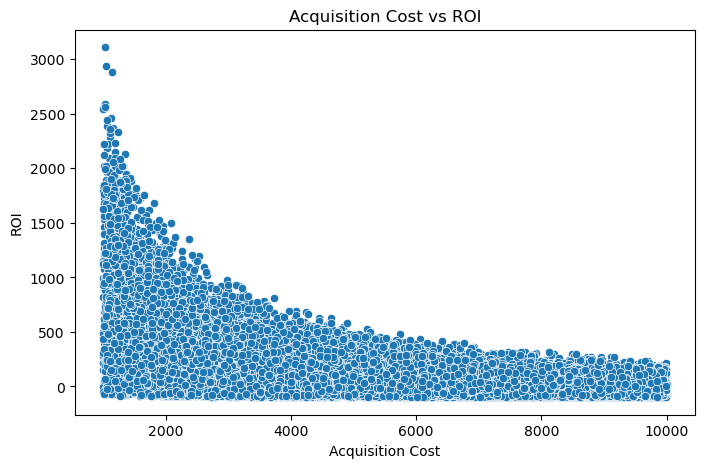

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Acquisition_Cost',
    y='ROI'
)

plt.title('Acquisition Cost vs ROI')
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')

plt.show()

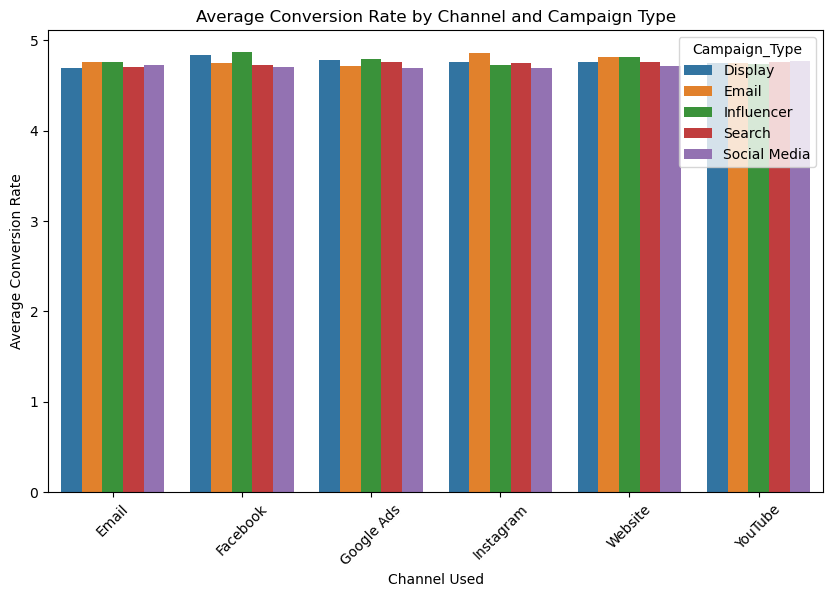

In [18]:
avg_conversion = df.groupby(
    ['Channel_Used', 'Campaign_Type']
)['Conversion_Rate'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=avg_conversion,
    x='Channel_Used',
    y='Conversion_Rate',
    hue='Campaign_Type'
)

plt.title('Average Conversion Rate by Channel and Campaign Type')
plt.xlabel('Channel Used')
plt.ylabel('Average Conversion Rate')

plt.xticks(rotation=45)
plt.show()

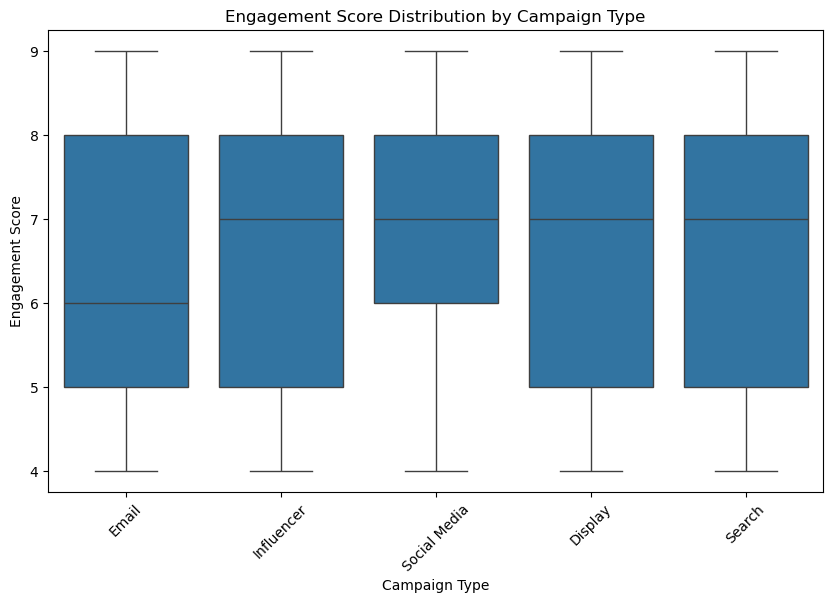

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Campaign_Type',
    y='Engagement_Score'
)

plt.title('Engagement Score Distribution by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Engagement Score')

plt.xticks(rotation=45)
plt.show()

In [20]:
avg_roi_company = df.groupby('Company')['ROI'].mean().sort_values(ascending=False)

print(avg_roi_company)

Company
Alpha Innovations      187.802897
NexGen Systems         187.216772
Innovate Industries    181.513559
Data Tech Solutions    179.493878
TechCorp               178.355158
Name: ROI, dtype: float64


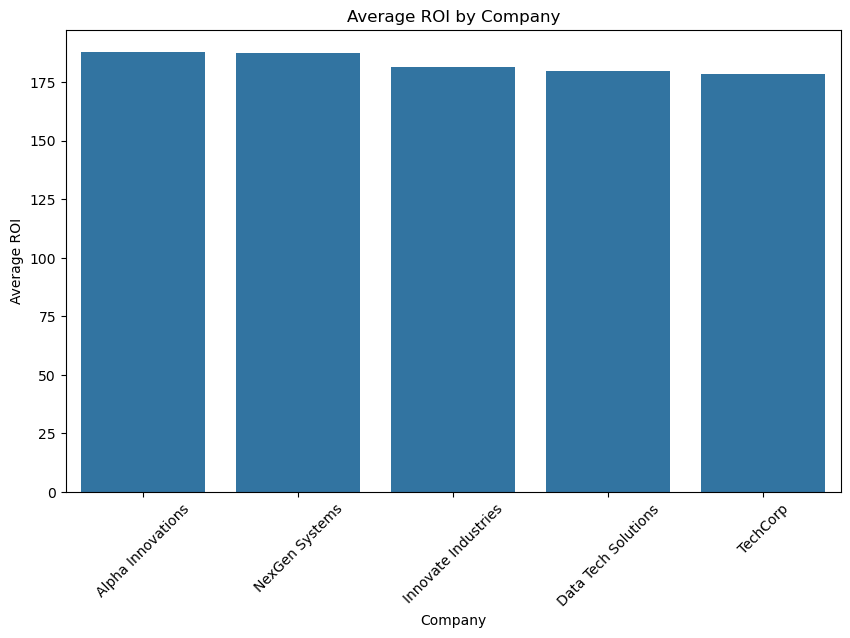

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_roi_company.index,
    y=avg_roi_company.values
)

plt.title('Average ROI by Company')
plt.xlabel('Company')
plt.ylabel('Average ROI')

plt.xticks(rotation=45)
plt.show()

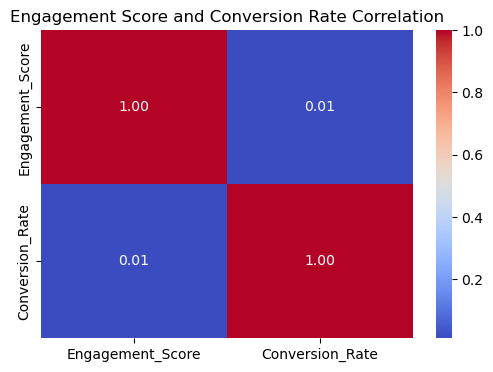

In [22]:
correlation = df[
    ['Engagement_Score', 'Conversion_Rate']
].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Engagement Score and Conversion Rate Correlation')

plt.show()

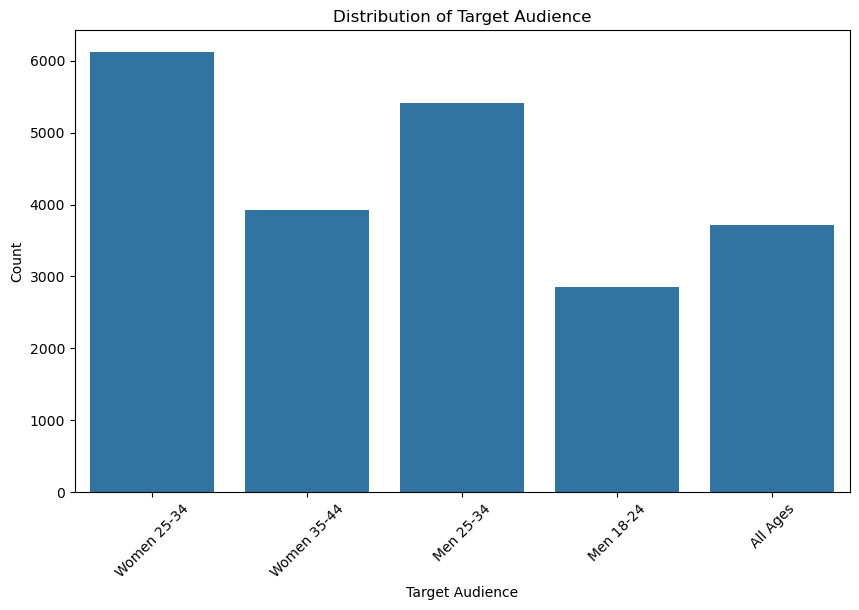

In [24]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Target_Audience'
)

plt.title('Distribution of Target Audience')
plt.xlabel('Target Audience')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.show()

In [25]:
segment_language = df.groupby(
    ['Language', 'Customer_Segment']
)['Conversion_Rate'].mean().reset_index()

segment_language

,Language,Customer_Segment,Conversion_Rate
0,English,Fashionistas,5.012963
1,English,Foodies,4.993941
2,English,Health & Wellness,5.002077
3,English,Outdoor Adventurers,4.992591
4,English,Tech Enthusiasts,5.022731
5,French,Fashionistas,4.664790
6,French,Foodies,4.651853
7,French,Health & Wellness,4.689704
8,French,Outdoor Adventurers,4.610732
9,French,Tech Enthusiasts,4.624001


In [26]:
highest_conversion = segment_language.loc[
    segment_language.groupby('Language')['Conversion_Rate'].idxmax()
]

highest_conversion

,Language,Customer_Segment,Conversion_Rate
4,English,Tech Enthusiasts,5.022731
7,French,Health & Wellness,4.689704
11,German,Foodies,4.705430
17,Mandarin,Health & Wellness,4.756125
21,Spanish,Foodies,4.663610


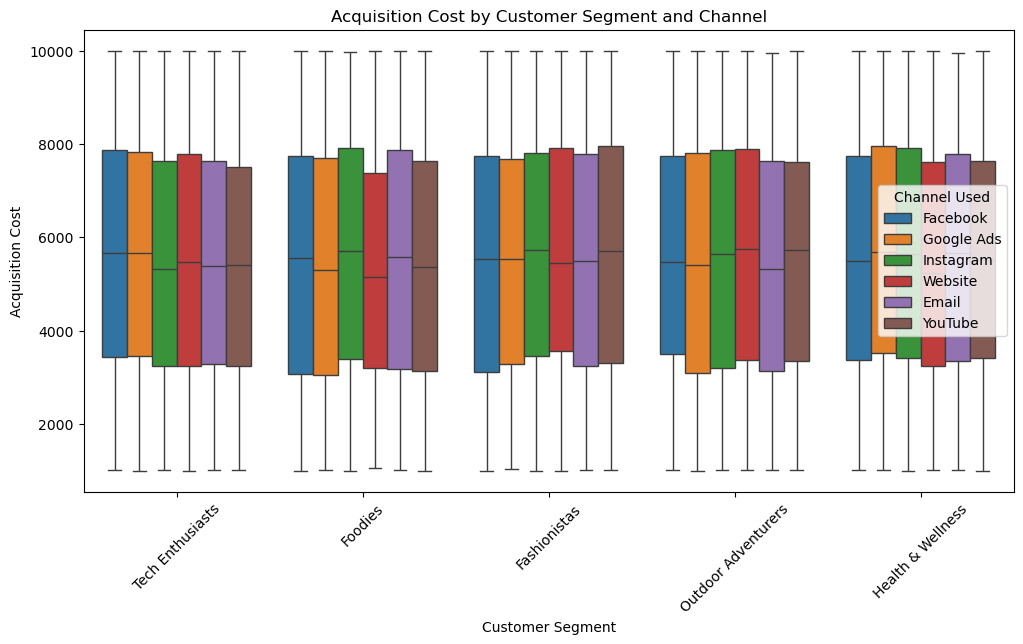

In [27]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Customer_Segment',
    y='Acquisition_Cost',
    hue='Channel_Used'
)

plt.title('Acquisition Cost by Customer Segment and Channel')
plt.xlabel('Customer Segment')
plt.ylabel('Acquisition Cost')

plt.xticks(rotation=45)
plt.legend(title='Channel Used')

plt.show()

In [28]:
avg_conversion_language = df.groupby(
    'Language'
)['Conversion_Rate'].mean().sort_values(ascending=False)

print(avg_conversion_language)

Language
English     5.005043
Mandarin    4.701252
French      4.647769
German      4.647514
Spanish     4.630547
Name: Conversion_Rate, dtype: float64


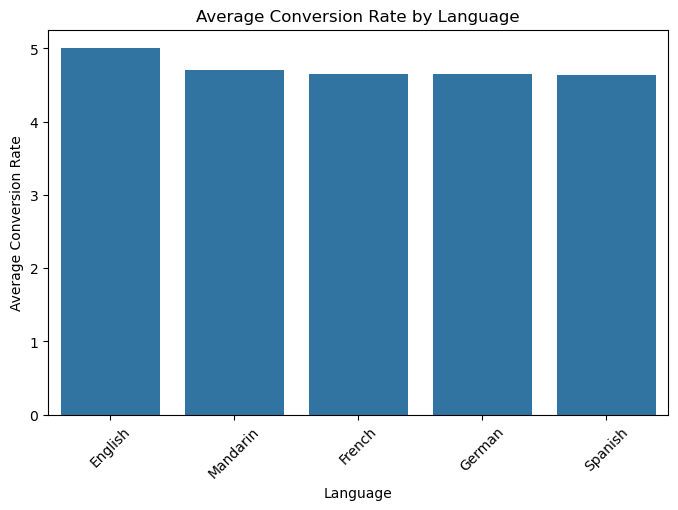

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_conversion_language.index,
    y=avg_conversion_language.values
)

plt.title('Average Conversion Rate by Language')
plt.xlabel('Language')
plt.ylabel('Average Conversion Rate')

plt.xticks(rotation=45)
plt.show()

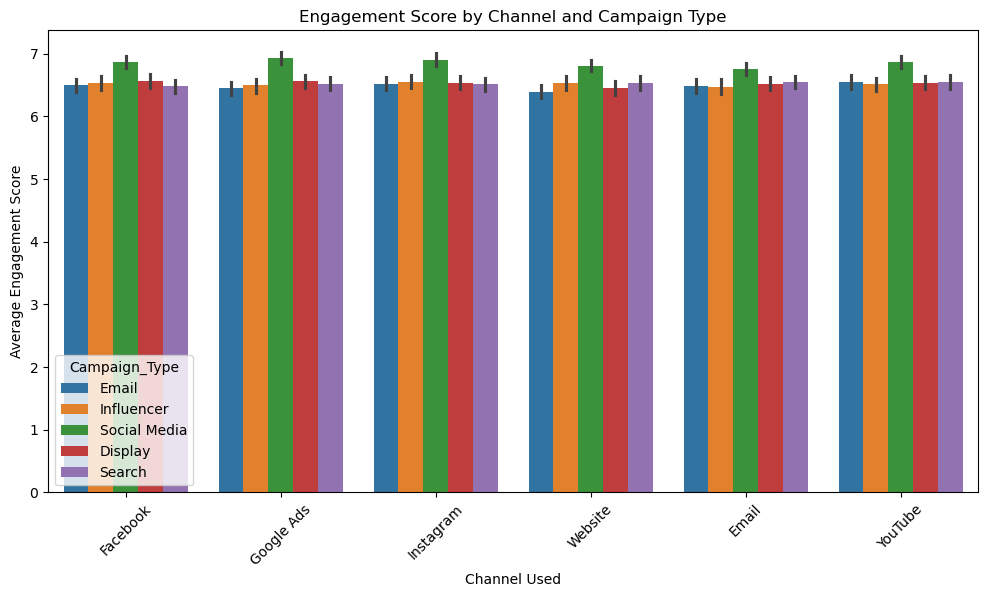

In [30]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x='Channel_Used',
    y='Engagement_Score',
    hue='Campaign_Type'
)

plt.title('Engagement Score by Channel and Campaign Type')
plt.xlabel('Channel Used')
plt.ylabel('Average Engagement Score')

plt.xticks(rotation=45)

plt.show()

In [31]:
total_roi_channel = df.groupby('Channel_Used')['ROI'].sum()

print(total_roi_channel)

Channel_Used
Email         673804.39
Facebook      704684.82
Google Ads    678232.24
Instagram     646462.11
Website       664577.42
YouTube       660542.33
Name: ROI, dtype: float64


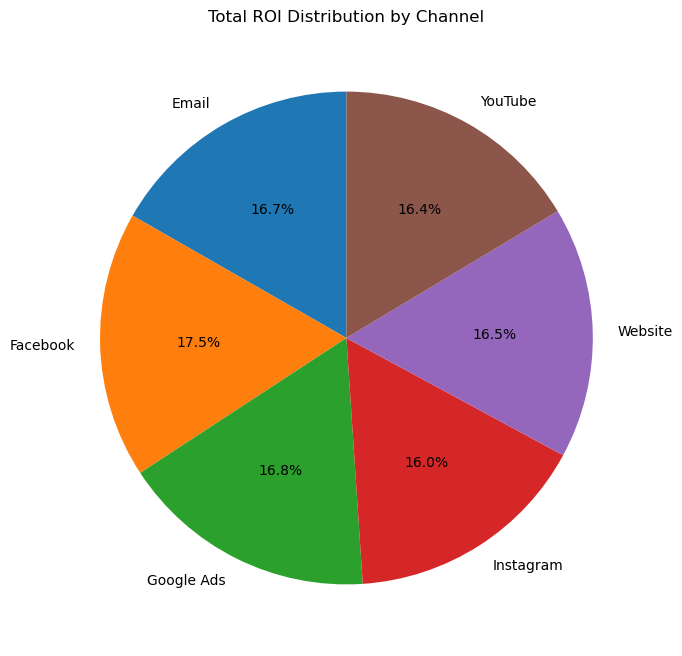

In [32]:
plt.figure(figsize=(8, 8))

plt.pie(
    total_roi_channel,
    labels=total_roi_channel.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Total ROI Distribution by Channel')

plt.show()

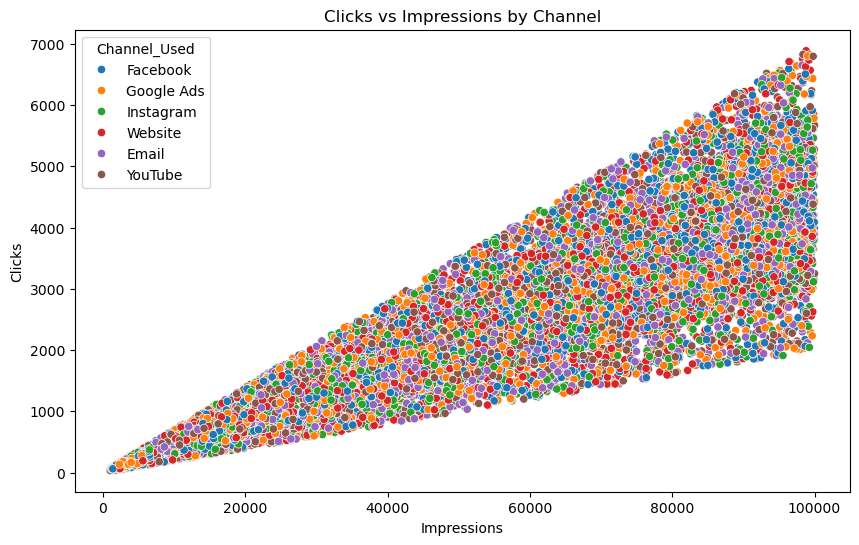

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Impressions',
    y='Clicks',
    hue='Channel_Used'
)

plt.title('Clicks vs Impressions by Channel')
plt.xlabel('Impressions')
plt.ylabel('Clicks')

plt.show()

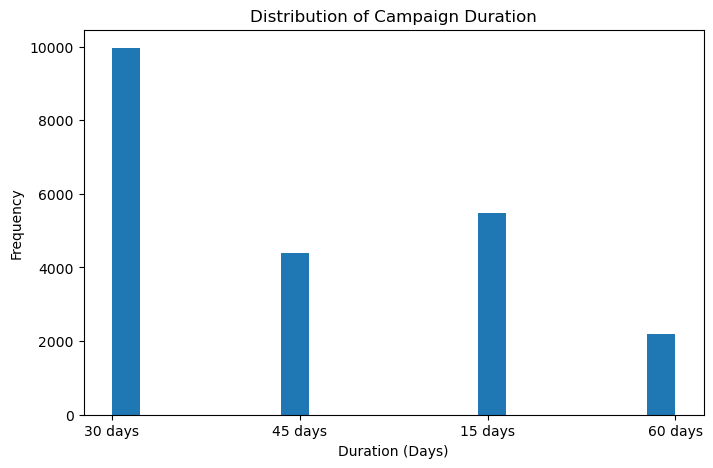

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['Duration'],
    bins=20
)

plt.title('Distribution of Campaign Duration')
plt.xlabel('Duration (Days)')
plt.ylabel('Frequency')

plt.show()

In [38]:
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

In [40]:
date_company_conversion = df.groupby(
    ['Date', 'Company']
)['Conversion_Rate'].mean().reset_index()

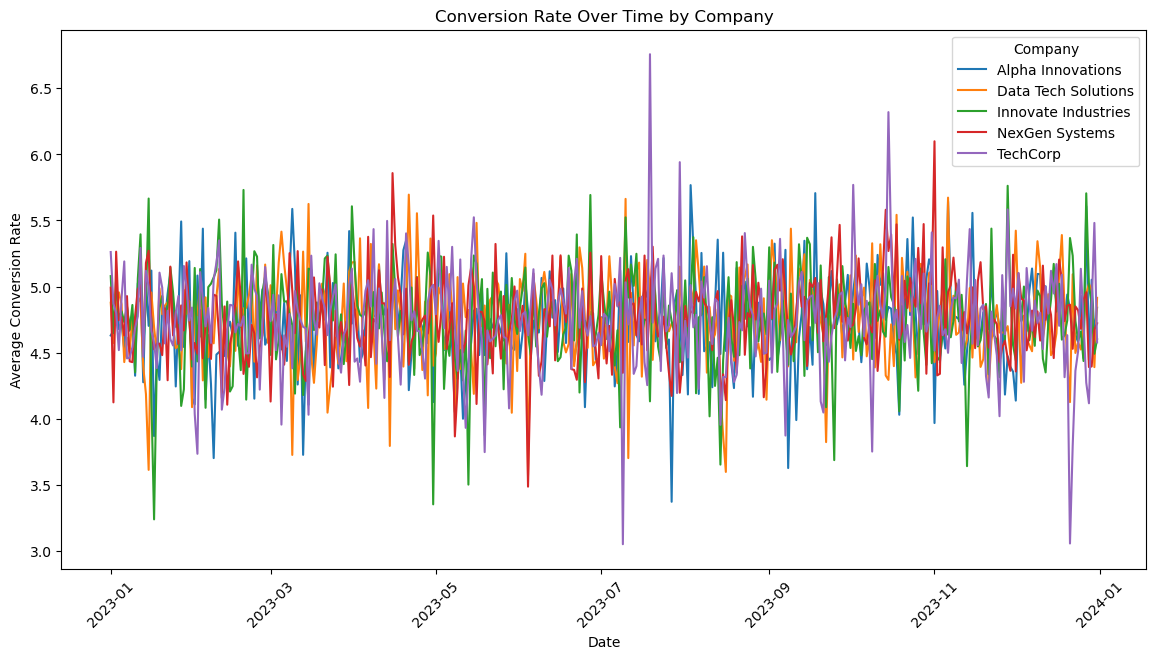

In [41]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=date_company_conversion,
    x='Date',
    y='Conversion_Rate',
    hue='Company'
)

plt.title('Conversion Rate Over Time by Company')
plt.xlabel('Date')
plt.ylabel('Average Conversion Rate')

plt.xticks(rotation=45)

plt.show()

In [42]:
date_engagement = df.groupby(
    'Date'
)['Engagement_Score'].mean().reset_index()

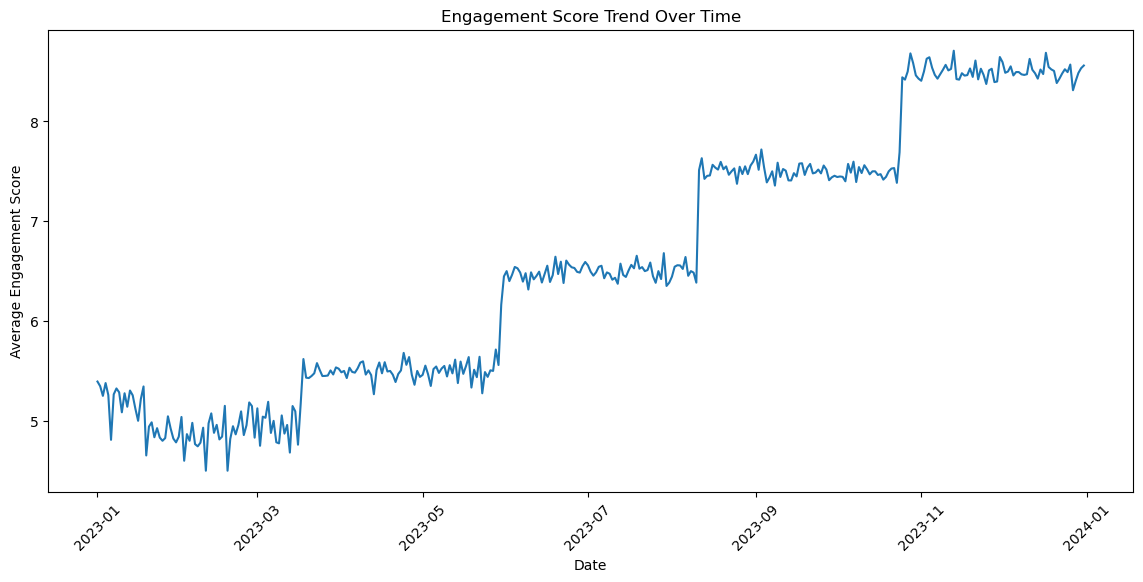

In [43]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=date_engagement,
    x='Date',
    y='Engagement_Score'
)

plt.title('Engagement Score Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Engagement Score')

plt.xticks(rotation=45)

plt.show()

In [44]:
avg_acquisition_location = df.groupby(
    'Location'
)['Acquisition_Cost'].mean().sort_values(ascending=False)

print(avg_acquisition_location)

Location
New York            5650.628611
Seattle             5554.233244
Miami               5540.965548
San Francisco       5539.129406
Los Angeles         5523.579550
Houston             5506.697022
Chicago             5493.182466
Atlanta             5483.208812
Washington, D.C.    5476.729717
Dallas              5459.544118
Name: Acquisition_Cost, dtype: float64


In [45]:
highest_location = avg_acquisition_location.idxmax()
highest_cost = avg_acquisition_location.max()

print("Location with highest Acquisition Cost:", highest_location)
print("Average Acquisition Cost:", highest_cost)

Location with highest Acquisition Cost: New York
Average Acquisition Cost: 5650.628611369991


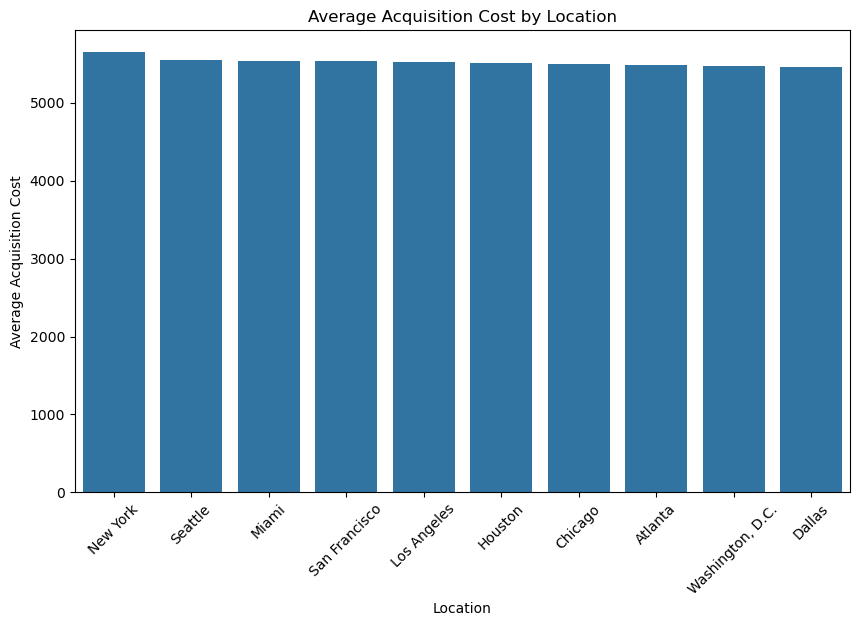

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_acquisition_location.index,
    y=avg_acquisition_location.values
)

plt.title('Average Acquisition Cost by Location')
plt.xlabel('Location')
plt.ylabel('Average Acquisition Cost')

plt.xticks(rotation=45)

plt.show()

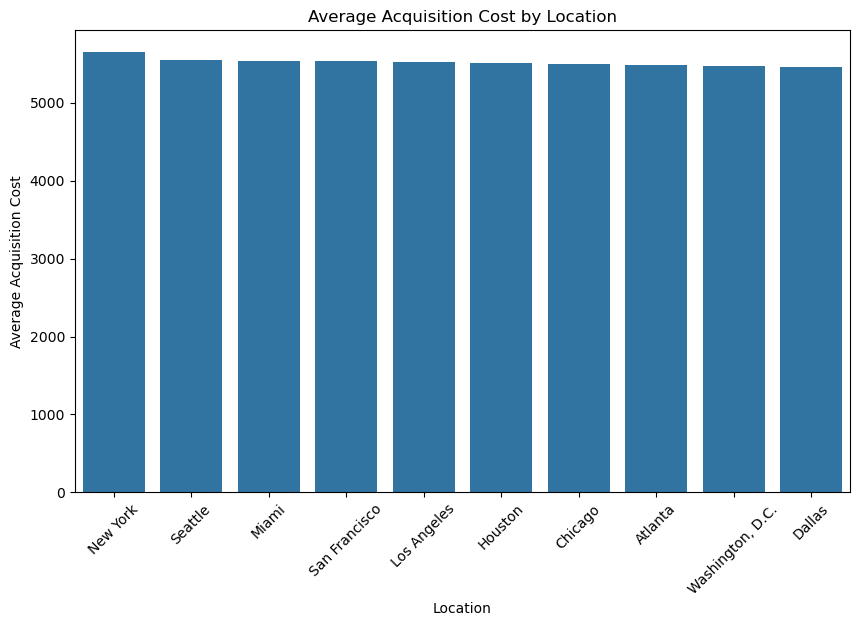

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_acquisition_location.index,
    y=avg_acquisition_location.values
)

plt.title('Average Acquisition Cost by Location')
plt.xlabel('Location')
plt.ylabel('Average Acquisition Cost')

plt.xticks(rotation=45)

plt.show()

In [48]:
total_roi_location = df.groupby(
    'Location'
)['ROI'].sum()

print(total_roi_location)

Location
Atlanta             384348.19
Chicago             432257.42
Dallas              422771.06
Houston             427727.23
Los Angeles         416718.64
Miami               400086.36
New York            380121.73
San Francisco       374367.54
Seattle             390251.85
Washington, D.C.    399653.29
Name: ROI, dtype: float64


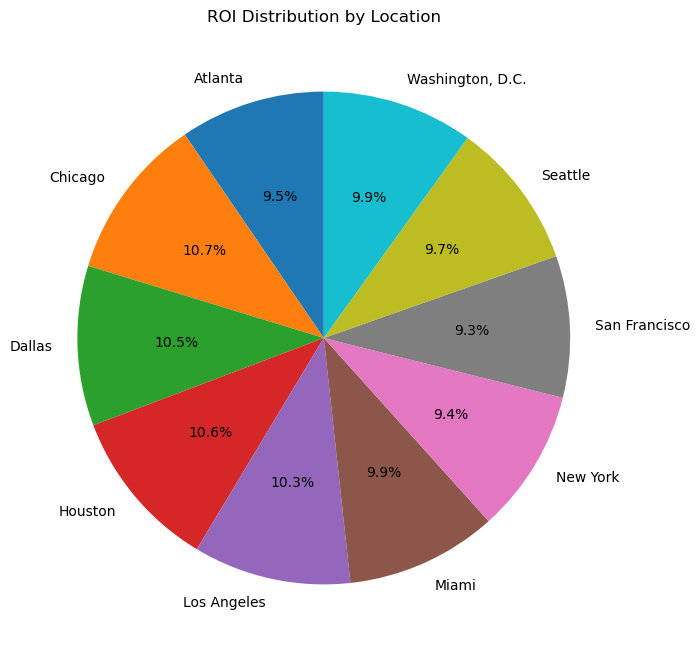

In [49]:
plt.figure(figsize=(8, 8))

plt.pie(
    total_roi_location,
    labels=total_roi_location.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('ROI Distribution by Location')

plt.show()